# Penalty -> Log-Barrier Solver: CPU vs GPU

Compares the numpy/scipy L-BFGS-B (CPU) and torch L-BFGS (GPU)
implementations of the penalty -> barrier solver across 2D and 3D test
cases. Reports neg-Jdet, min Jdet, L2 distortion, and wall time for
each (case, backend) pair.

**Expectation:** GPU has fixed launch overhead (~1-2 s/L-BFGS step), so
small problems (a few thousand voxels) will be slower on GPU; large
problems (~1M+ voxels) win big on GPU. The crossover sits around
10k-100k variables on this hardware (RTX 3050).

In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
import torch

from test_cases import make_deformation
from dvfopt import jacobian_det2D, jacobian_det3D, scale_dvf_3d, generate_random_dvf_3d
from dvfopt.core.iterative2d_barrier import iterative_2d_barrier, iterative_2d_barrier_torch
from dvfopt.core.iterative3d_barrier import iterative_3d_barrier
from dvfopt.core.iterative3d_barrier_torch import iterative_3d_barrier_torch

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Device:', torch.cuda.get_device_name(0))

CUDA available: True
Device: NVIDIA GeForce RTX 3050 OEM


## Helpers

In [2]:
def init_stats_2d(deformation):
    H, W = deformation.shape[-2:]
    phi = np.stack([deformation[1, 0], deformation[2, 0]])  # (2,H,W)
    j = jacobian_det2D(phi)[0]
    return int((j <= 0).sum()), float(j.min()), H * W, (H, W)

def final_stats_2d(phi_out, deformation):
    j = jacobian_det2D(phi_out)[0]
    phi_init = np.stack([deformation[1, 0], deformation[2, 0]])
    return int((j <= 0).sum()), float(j.min()), float(np.linalg.norm(phi_out - phi_init))

def init_stats_3d(dvf):
    j = jacobian_det3D(dvf)
    D, H, W = dvf.shape[1:]
    return int((j <= 0).sum()), float(j.min()), D * H * W, (D, H, W)

def final_stats_3d(phi, dvf):
    j = jacobian_det3D(phi)
    return int((j <= 0).sum()), float(j.min()), float(np.linalg.norm(phi - dvf))

def time_call(fn, *args, **kwargs):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.time()
    out = fn(*args, **kwargs)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return out, time.time() - t0

## 2D test cases

Three sizes from `test_cases` covering small (10x10), medium (20x20),
and somewhat larger (20x40) grids.

In [3]:
CASES_2D = ['01a_10x10_crossing', '03c_20x20_opposite', '01c_20x40_edges']
rows_2d = []
for key in CASES_2D:
    deformation, *_ = make_deformation(key)
    init_neg, init_min, n_vox, shape = init_stats_2d(deformation)
    if init_neg == 0:
        print(f'{key}: no negatives, skipping')
        continue
    phi_cpu, t_cpu = time_call(iterative_2d_barrier, deformation, verbose=0)
    phi_gpu, t_gpu = time_call(iterative_2d_barrier_torch, deformation, verbose=0)
    fn_cpu, fm_cpu, l2_cpu = final_stats_2d(phi_cpu, deformation)
    fn_gpu, fm_gpu, l2_gpu = final_stats_2d(phi_gpu, deformation)
    rows_2d.append((key, shape, n_vox, init_neg, init_min,
                    t_cpu, fn_cpu, fm_cpu, l2_cpu,
                    t_gpu, fn_gpu, fm_gpu, l2_gpu))

print()
print(f'{"case":<25s} {"shape":>10s} {"vox":>6s} {"neg0":>5s} '
      f'{"t_cpu":>8s} {"neg_cpu":>8s} {"L2_cpu":>8s} '
      f'{"t_gpu":>8s} {"neg_gpu":>8s} {"L2_gpu":>8s} {"speedup":>8s}')
for r in rows_2d:
    key, shape, nv, n0, m0, tc, nc, mc, lc, tg, ng, mg, lg = r
    sh = f'{shape[0]}x{shape[1]}'
    print(f'{key:<25s} {sh:>10s} {nv:>6d} {n0:>5d} '
          f'{tc:>8.2f} {nc:>8d} {lc:>8.4f} '
          f'{tg:>8.2f} {ng:>8d} {lg:>8.4f} {tc/tg:>7.2f}x')

Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A
Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A
Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A

case                           shape    vox  neg0    t_cpu  neg_cpu   L2_cpu    t_gpu  neg_gpu   L2_gpu  speedup
01a_10x10_crossing             10x10    100     9     0.06        0   2.2751     1.97        0   2.2751    0.03x
03c_20x20_opposite             20x20    400    34     0.27        0   3.8734     6.21        0   3.8734    0.04x
01c_20x40_edges                20x40    800    32     0.17        0   2.9162     2.92        0   2.9162    0.06x


## 3D test cases

Synthetic random fields at a few sizes plus the downsampled real volume
(`(132, 80, 114)`, the case that livelocked SLSQP).

In [4]:
BASE_SHAPE = (3, 3, 3, 3)
MAX_MAGNITUDE = 4.0
SEED = 42
DOWNSAMPLE_FACTOR = 1 / 4
FULL_VOLUME_PATH = '../../../data/corrected_correspondences_count_touching/registered_output/deformation3d.npy'

base_dvf = generate_random_dvf_3d(BASE_SHAPE, MAX_MAGNITUDE, SEED)
synthetic_3d = {}
for size in [(8, 8, 8), (16, 16, 16), (32, 32, 32)]:
    synthetic_3d[f'{size[0]}x{size[1]}x{size[2]}'] = scale_dvf_3d(base_dvf, size)

if os.path.exists(FULL_VOLUME_PATH):
    full = np.load(FULL_VOLUME_PATH)
    _, Df, Hf, Wf = full.shape
    new_shape = (max(1, int(round(Df * DOWNSAMPLE_FACTOR))),
                 max(1, int(round(Hf * DOWNSAMPLE_FACTOR))),
                 max(1, int(round(Wf * DOWNSAMPLE_FACTOR))))
    synthetic_3d['real_ds'] = scale_dvf_3d(full, new_shape)
    del full
    print('Loaded real volume ->', new_shape)
else:
    print('Skipping real volume:', FULL_VOLUME_PATH, 'not found')

for k, dvf in synthetic_3d.items():
    n0, m0, nv, _ = init_stats_3d(dvf)
    print(f'  {k:>14s}  vox={nv:>10d}  neg0={n0:>5d}  min0={m0:+.3f}')

Loaded real volume -> (132, 80, 114)
           8x8x8  vox=       512  neg0=  244  min0=-43.271
        16x16x16  vox=      4096  neg0= 1810  min0=-35.490
        32x32x32  vox=     32768  neg0=14118  min0=-32.303
         real_ds  vox=   1203840  neg0=  296  min0=-11.202


In [5]:
rows_3d = []
for key, dvf in synthetic_3d.items():
    init_neg, init_min, n_vox, shape = init_stats_3d(dvf)
    print(f'\n=== {key}  shape={shape}  init_neg={init_neg}  init_min={init_min:+.3f}  vox={n_vox}', flush=True)
    print('  running CPU ...', flush=True)
    phi_cpu, t_cpu = time_call(iterative_3d_barrier, dvf, verbose=0)
    fn_cpu, fm_cpu, l2_cpu = final_stats_3d(phi_cpu, dvf)
    print(f'    CPU: neg->{fn_cpu}  min->{fm_cpu:+.5f}  L2={l2_cpu:.4f}  t={t_cpu:.2f}s', flush=True)
    print('  running GPU ...', flush=True)
    phi_gpu, t_gpu = time_call(iterative_3d_barrier_torch, dvf, verbose=0)
    fn_gpu, fm_gpu, l2_gpu = final_stats_3d(phi_gpu, dvf)
    print(f'    GPU: neg->{fn_gpu}  min->{fm_gpu:+.5f}  L2={l2_gpu:.4f}  t={t_gpu:.2f}s', flush=True)
    rows_3d.append((key, shape, n_vox, init_neg, init_min,
                    t_cpu, fn_cpu, fm_cpu, l2_cpu,
                    t_gpu, fn_gpu, fm_gpu, l2_gpu))

print()
print(f'{"case":<14s} {"shape":>14s} {"vox":>10s} {"neg0":>5s} '
      f'{"t_cpu":>9s} {"neg_cpu":>8s} {"L2_cpu":>8s} '
      f'{"t_gpu":>9s} {"neg_gpu":>8s} {"L2_gpu":>8s} {"speedup":>8s}')
for r in rows_3d:
    key, shape, nv, n0, m0, tc, nc, mc, lc, tg, ng, mg, lg = r
    sh = f'{shape[0]}x{shape[1]}x{shape[2]}'
    print(f'{key:<14s} {sh:>14s} {nv:>10d} {n0:>5d} '
          f'{tc:>9.2f} {nc:>8d} {lc:>8.4f} '
          f'{tg:>9.2f} {ng:>8d} {lg:>8.4f} {tc/tg:>7.2f}x')


=== 8x8x8  shape=(8, 8, 8)  init_neg=244  init_min=-43.271  vox=512
  running CPU ...
    CPU: neg->0  min->+0.01100  L2=10.3945  t=0.98s
  running GPU ...
    GPU: neg->0  min->+0.01100  L2=10.3920  t=15.66s

=== 16x16x16  shape=(16, 16, 16)  init_neg=1810  init_min=-35.490  vox=4096
  running CPU ...
    CPU: neg->0  min->+0.01100  L2=40.7017  t=7.24s
  running GPU ...
    GPU: neg->0  min->+0.01100  L2=40.6681  t=18.97s

=== 32x32x32  shape=(32, 32, 32)  init_neg=14118  init_min=-32.303  vox=32768
  running CPU ...
    CPU: neg->0  min->+0.01100  L2=173.9281  t=23.08s
  running GPU ...
    GPU: neg->0  min->+0.01100  L2=172.5211  t=17.21s

=== real_ds  shape=(132, 80, 114)  init_neg=296  init_min=-11.202  vox=1203840
  running CPU ...
    CPU: neg->0  min->+0.01100  L2=9.8981  t=1142.18s
  running GPU ...
    GPU: neg->0  min->+0.01100  L2=9.8934  t=120.14s

case                    shape        vox  neg0     t_cpu  neg_cpu   L2_cpu     t_gpu  neg_gpu   L2_gpu  speedup
8x8x8        

## Speedup vs problem size

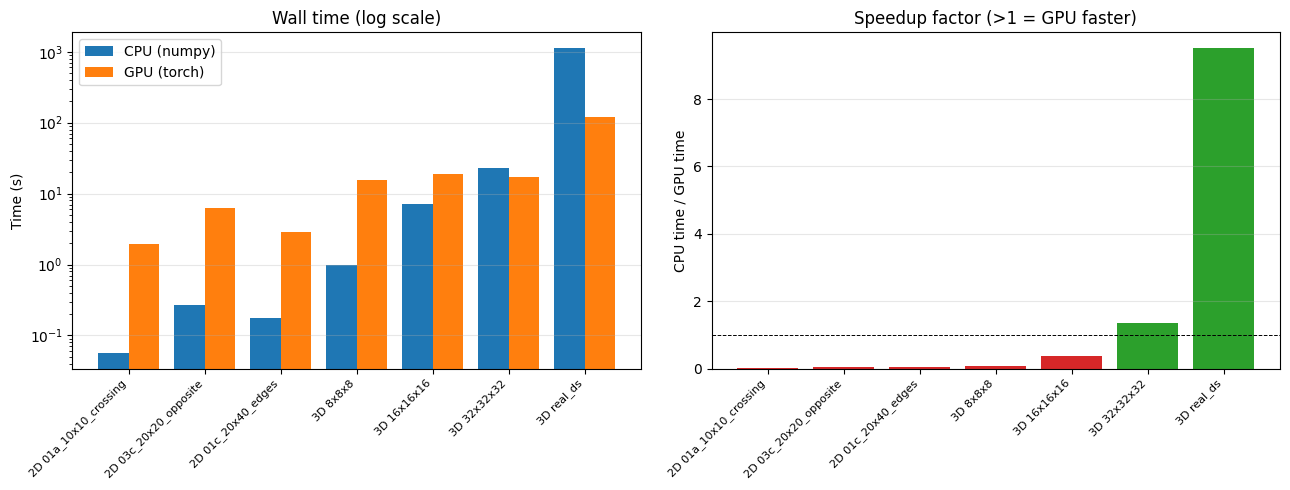

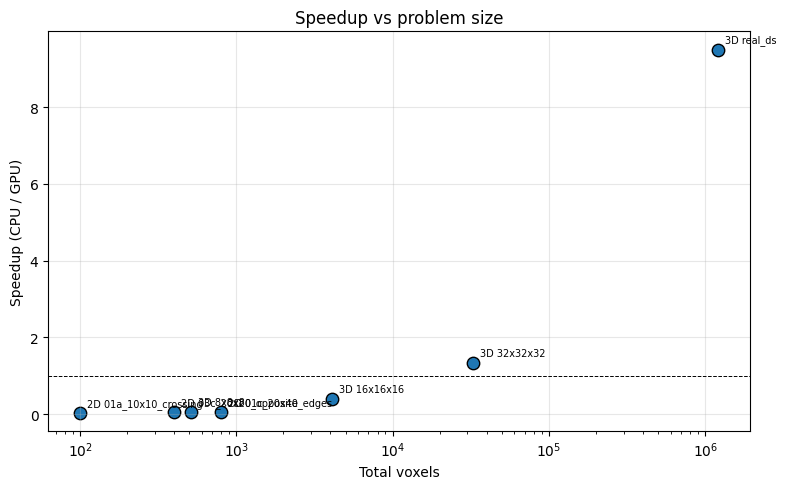

In [6]:
all_rows = [('2D ' + r[0], r[2], r[5], r[9]) for r in rows_2d] \
         + [('3D ' + r[0], r[2], r[5], r[9]) for r in rows_3d]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
labels = [r[0] for r in all_rows]
n_vox = [r[1] for r in all_rows]
t_cpu = [r[2] for r in all_rows]
t_gpu = [r[3] for r in all_rows]
x = np.arange(len(labels)); w = 0.4
ax.bar(x - w/2, t_cpu, w, label='CPU (numpy)', color='tab:blue')
ax.bar(x + w/2, t_gpu, w, label='GPU (torch)', color='tab:orange')
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Time (s)'); ax.set_title('Wall time (log scale)')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
speedup = [c / g for c, g in zip(t_cpu, t_gpu)]
colors = ['tab:green' if s > 1 else 'tab:red' for s in speedup]
ax.bar(x, speedup, color=colors)
ax.axhline(1.0, color='black', linestyle='--', linewidth=0.7)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('CPU time / GPU time')
ax.set_title('Speedup factor (>1 = GPU faster)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(n_vox, speedup, s=80, edgecolor='black')
for x_, y_, lab in zip(n_vox, speedup, labels):
    ax.annotate(lab, (x_, y_), fontsize=7, textcoords='offset points', xytext=(5, 5))
ax.set_xscale('log')
ax.axhline(1.0, color='black', linestyle='--', linewidth=0.7)
ax.set_xlabel('Total voxels'); ax.set_ylabel('Speedup (CPU / GPU)')
ax.set_title('Speedup vs problem size')
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()